# Washington Coast Sea State Forecasting with Machine Learning

**Author:** Brian Kane 

This project uses machine learning to forecast sea state and coastal weather along the Washington State coast. The idea came from wanting to build something actually useful for commercial fishing vessels operating off the Washington coast deal with some of the roughest conditions on the Pacific, and better short-term forecasts could make a real difference for safety.

We worked with six NDBC stations split into two groups: three offshore buoys that measure wave conditions directly, and three land-based surface stations that measure wind and pressure from shore.

**Stations:**
- Buoys: 46041 (Cape Elizabeth), 46087 (Neah Bay), 46211 (Grays Harbor)
- Land: DESW1 (Destruction Island), LAPW1 (La Push), WPTW1 (Westport)

**How the pipeline works:**
```
NDBC observations + ERA5 reanalysis → preprocessing → RF / GBM training → evaluation → operational forecast
```

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

Buoy_stations = ['46041', '46087', '46211']
Land_stations  = ['DESW1', 'LAPW1', 'WPTW1']
All_stations   = Buoy_stations + Land_stations

Station_coords = {
    '46041': (47.353, -124.731), '46087': (48.494, -124.728), '46211': (47.116, -124.184),
    'DESW1': (47.677, -124.499), 'LAPW1': (47.913, -124.637), 'WPTW1': (46.904, -124.105),
}

Merged_DIR = 'data/merged'
print('Imports loaded successfully.')

Imports loaded successfully.


---
## Part 1 Sources of Complexity

### 1.1 The Physical Problem

The Washington coast is not a simple environment to forecast. Wave height, period, and direction are all driven by a combination of local wind, distant swell arriving from storms hundreds of miles away, and the shape of the seafloor near the coast. These factors interact in ways that don't follow a straight line a small change in wind direction can produce a very different sea state depending on what swell is already running.

Each station also sits in a different exposure context. Station 46087 off Neah Bay faces the open Pacific directly and sees the full force of northwest swell. Station 46211 near Grays Harbor is partially sheltered by the bay geometry, so the same storm shows up differently there. The models have to learn these station-specific behaviors from data alone.

The safety-critical events aka the big storms are also the rarest in the dataset. Most of the training data represents calm or moderate conditions, which makes it harder for the models to learn the extreme cases well.

### 1.2 Directional Variables and the 0°/360° Problem

Wave direction (MWD) and wind direction (WDIR) are circular 1° and 359° are almost the same direction, but if you treat them as regular numbers a model will think they are completely opposite. This caused large errors early on and required a specific fix before training.

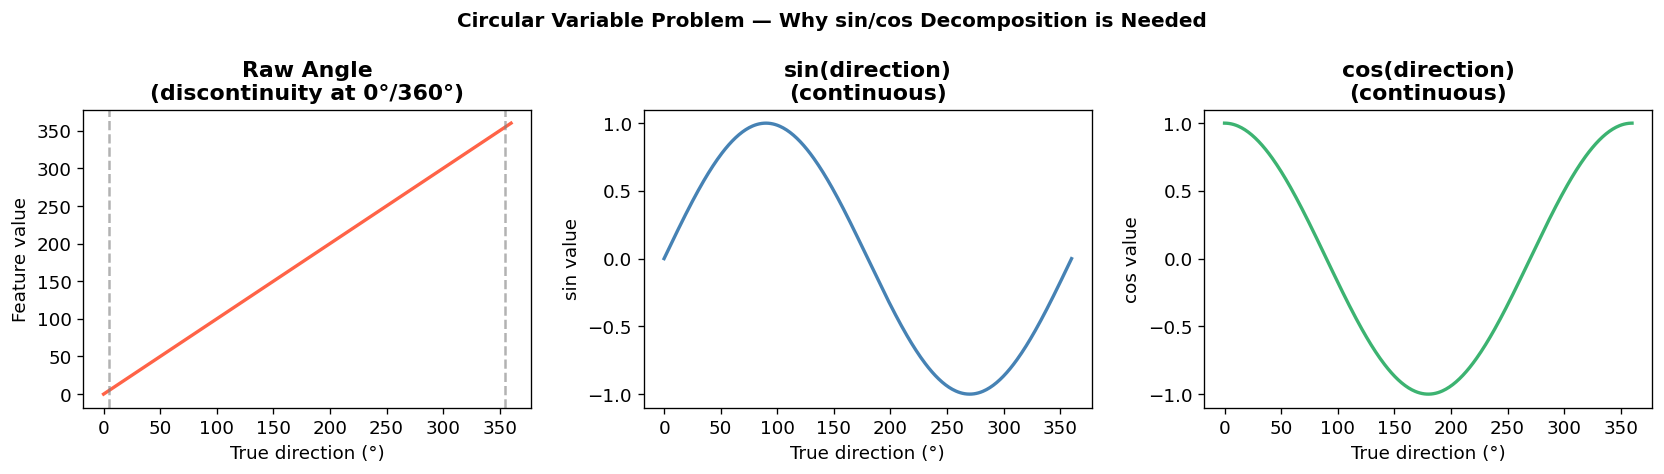

In [14]:
# Demonstrate the circular variable problem
angles = np.linspace(0, 360, 360)
sin_vals = np.sin(np.radians(angles))
cos_vals = np.cos(np.radians(angles))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Raw angle — discontinuity at 0/360
axes[0].plot(angles, angles, color='tomato', linewidth=2)
axes[0].axvline(355, color='gray', linestyle='--', alpha=0.6)
axes[0].axvline(5, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Raw Angle\n(discontinuity at 0°/360°)', fontweight='bold')
axes[0].set_xlabel('True direction (°)'); axes[0].set_ylabel('Feature value')

# Sin component
axes[1].plot(angles, sin_vals, color='steelblue', linewidth=2)
axes[1].set_title('sin(direction)\n(continuous)', fontweight='bold')
axes[1].set_xlabel('True direction (°)'); axes[1].set_ylabel('sin value')

# Cos component
axes[2].plot(angles, cos_vals, color='mediumseagreen', linewidth=2)
axes[2].set_title('cos(direction)\n(continuous)', fontweight='bold')
axes[2].set_xlabel('True direction (°)'); axes[2].set_ylabel('cos value')

plt.suptitle('Circular Variable Problem — Why sin/cos Decomposition is Needed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 Station Types and Why Some Data Is Always Missing

One of the first things we ran into was that some variables were just always missing for certain stations. At first it looked like a data problem, but it turned out to be physical it comes down to what each station is and where it's built.

**Buoy stations (46041, 46087, 46211)** float offshore in open water. Because they're sitting on the ocean surface, they have wave sensors that can directly measure wave height, period, and direction. They do go offline sometimes storms damage equipment, sensors fail, maintenance pulls them out of the water so you get gaps in the record

**Land stations (DESW1, LAPW1, WPTW1)** are fixed structures on shore lighthouses and coastal weather platforms. They measure wind and pressure just fine, but they have no wave sensors and there's no reason to put one on them. The ocean waves don't reach them in any meaningful way. So WVHT, DPD, and MWD are not missing by accident at these stations they were never going to be there. This is a hardware reality, not a gap in the dataset.

Once we understood this, it became clear that we needed completely separate model setups for each station type:

| Station Type | Predicts | ERA5 Features Used |
|-------------|----------|--------------------|
| Buoy (offshore) | WVHT, DPD, MWD | `swh, mwp, mwd, u10, v10, sp, t2m, tp` (8 features) |
| Land (onshore) | WSPD, WDIR, PRES | `u10, v10, sp, t2m, tp` (5 features — no wave data) |

Land stations also turned out to be harder to predict for wind direction specifically. Coastal terrain and local geography channel the wind in ways that ERA5's 28 km grid resolution just can't see.

### 1.4 Data Challenges: Missing Values and Temporal Gaps

In [15]:
# Load all merged datasets — used throughout the notebook
datasets = {}

for station in All_stations:
    path = os.path.join(Merged_DIR, f'{station}_merged.csv')
    df = pd.read_csv(path, index_col='time', parse_dates=True)
    datasets[station] = df

print(f"{'Station':<10} {'Type':<8} {'Start':<22} {'End':<22} {'Rows':>8}")
print('-' * 75)
for station, df in datasets.items():
    stype = 'Buoy' if station in Buoy_stations else 'Land'
    print(f"{station:<10} {stype:<8} {str(df.index.min()):<22} {str(df.index.max()):<22} {len(df):>8}")

print('\nDatasets loaded.')

Station    Type     Start                  End                        Rows
---------------------------------------------------------------------------
46041      Buoy     2021-01-01 00:00:00    2023-12-31 23:00:00       26280
46087      Buoy     2022-09-23 01:00:00    2023-12-31 23:00:00       11159
46211      Buoy     2021-01-01 00:00:00    2023-12-31 23:00:00       26280
DESW1      Land     2021-01-01 00:00:00    2023-12-31 23:00:00       26280
LAPW1      Land     2021-01-01 00:00:00    2023-12-31 23:00:00       26280
WPTW1      Land     2021-01-01 00:00:00    2023-12-31 23:00:00       26280

Datasets loaded.


### 1.5 ERA5 Grid vs Station Locations

ERA5 reanalysis comes on a 0.25° grid, which is roughly 28 km between points. Several of our stations sit right on the coastline, which means the nearest ERA5 grid point sometimes falls over land  and over land, wave variables like `swh`, `mwp`, and `mwd` are undefined. We had to write a fallback that searches nearby offshore grid points until it finds one with valid ocean data.

### 1.5 Summary of Complexity Sources

| Source | Challenge |
|--------|-----------|
| Wave physics | Nonlinear coupling between wind, swell, and bathymetry |
| Station equipment | Buoys measure waves; land stations cannot structural missing data by design |
| Directional variables | Circular discontinuity at 0°/360° cannot regress directly |
| Missing observations | Buoy downtime creates temporal gaps in training labels |
| Spatial resolution | ERA5 grid (~28 km) vs point-scale station measurements |
| Coastal terrain | Local wind channeling at land stations not captured by ERA5 |
| Class imbalance | Storm events are rare but most safety-critical |
| Multi-target | 3 variables per buoy station, 3 per land station, 18 models total |

---
## Part 2 Machine Learning Framework

### 2.1 Approach

We trained one model per variable per station, 18 models total. The idea was to keep each model focused on one specific task rather than trying to predict everything at once. Two model types were tested and compared:

| Model | Library | Hyperparameters | Output dir |
|-------|---------|-----------------|------------|
| Random Forest (RF) | scikit-learn | 100 trees, no max_depth | `models/` |
| XGBoost / GBM | xgboost | 200 trees, lr=0.05, max_depth=6 | `models_gbm/` |

Both are tree-based ensemble methods, which was a deliberate choice. Wave and wind relationships are nonlinear ERA5 wind speed doesn't map to wave height through a simple equation and tree-based models handle that naturally without needing us to specify the relationship upfront.

### 2.2 How the ML Framework Addresses Each Source of Complexity

| Complexity (from Part 1) | How the ML Framework Addresses It |
|--------------------------|-----------------------------------|
| Nonlinear wave physics | Tree splits don't assume linearity they find thresholds in the data |
| Station equipment constraints | Separate model sets for buoys (8 features) and land stations (5 features) |
| Directional variable discontinuity | Sin/cos decomposition before training; arctan2 reconstruction after prediction |
| Temporal gaps in observations | Rows with NaN targets are dropped per-target so each model trains on its own clean subset |
| ERA5 spatial mismatch | Nearest-valid-ocean-point fallback in preprocessing; ERA5 still captures the large-scale forcing |
| Coastal terrain at land stations | Known limitation flagged in results, ERA5 can't resolve local wind channeling |
| Storm event rarity | GBM's boosting puts more weight on the hard residuals, which are usually the storm cases |
| 18-model scale | Same `train_model()` function runs in a loop, adding a station is a one-line change |

### 2.3 Feature Engineering — Directional Decomposition

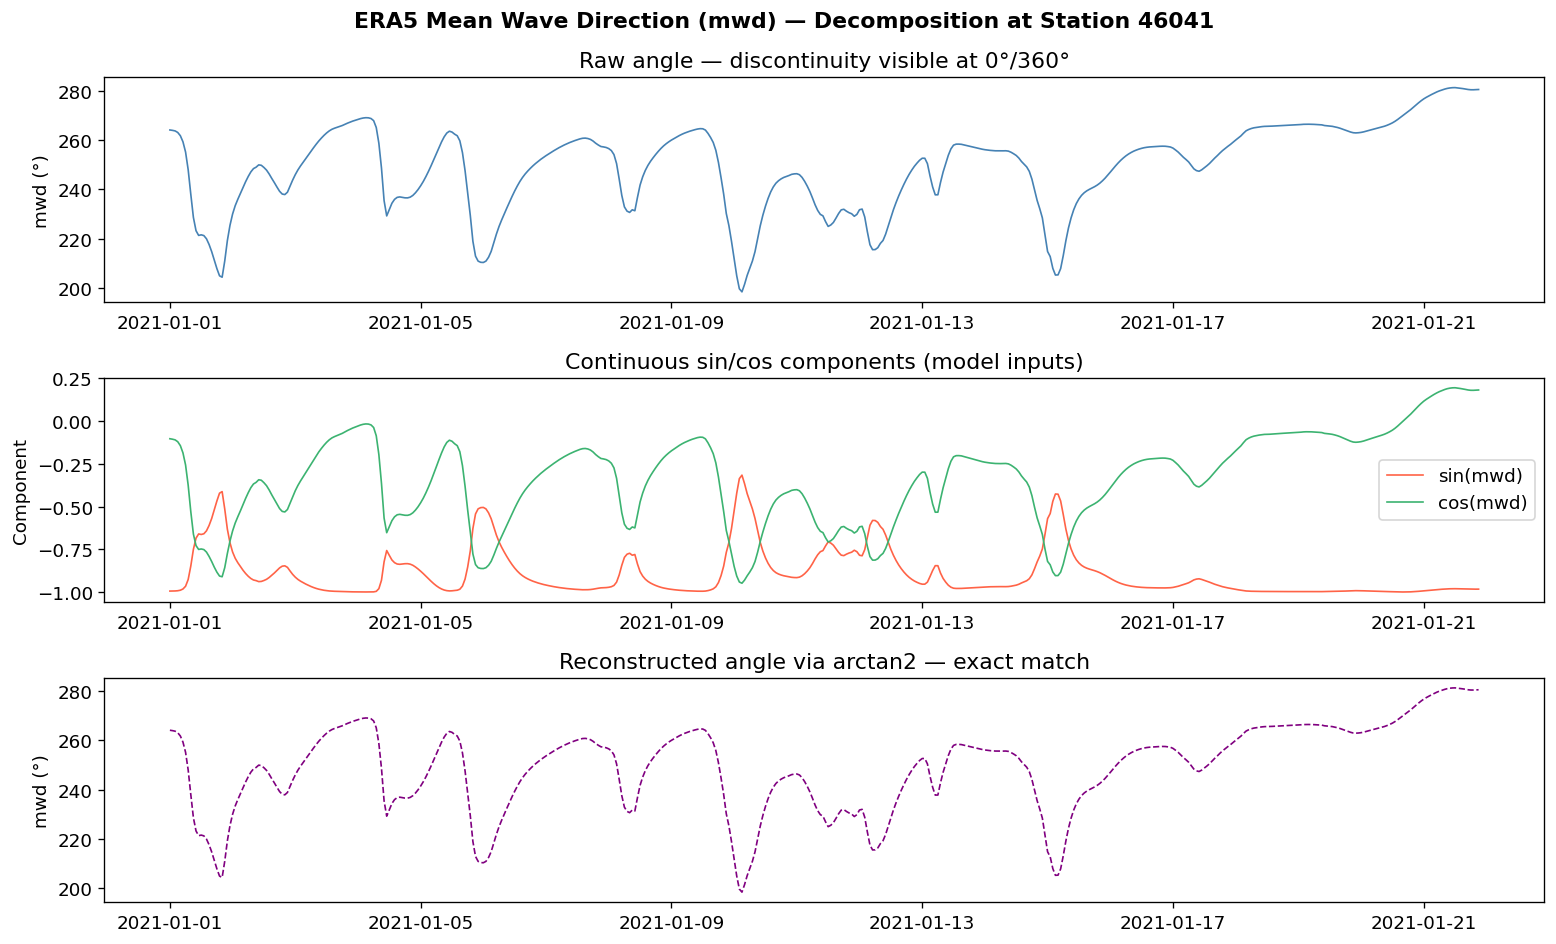

In [16]:
# Show the sin/cos decomposition and reconstruction for station 46041 MWD
df = datasets['46041'].dropna(subset=['mwd', 'MWD'])
sample = df[['mwd', 'MWD']].head(500).copy()

sample['mwd_sin'] = np.sin(np.radians(sample['mwd']))
sample['mwd_cos'] = np.cos(np.radians(sample['mwd']))

fig, axes = plt.subplots(3, 1, figsize=(13, 8))
fig.suptitle('ERA5 Mean Wave Direction (mwd) — Decomposition at Station 46041', fontweight='bold')

axes[0].plot(sample.index, sample['mwd'], color='steelblue', linewidth=1)
axes[0].set_ylabel('mwd (°)'); axes[0].set_title('Raw angle — discontinuity visible at 0°/360°')

axes[1].plot(sample.index, sample['mwd_sin'], color='tomato', linewidth=1, label='sin(mwd)')
axes[1].plot(sample.index, sample['mwd_cos'], color='mediumseagreen', linewidth=1, label='cos(mwd)')
axes[1].set_ylabel('Component'); axes[1].set_title('Continuous sin/cos components (model inputs)')
axes[1].legend()

reconstructed = np.degrees(np.arctan2(sample['mwd_sin'], sample['mwd_cos'])) % 360
axes[2].plot(sample.index, reconstructed, color='purple', linewidth=1, linestyle='--')
axes[2].set_ylabel('mwd (°)'); axes[2].set_title('Reconstructed angle via arctan2 — exact match')

plt.tight_layout()
plt.show()

### 2.4 ERA5 Predictor Variables

These are the **input features** fed into the models, they are not predicted outputs.

| Feature | Description | Unit | Buoy | Land |
|---------|-------------|------|------|------|
| `swh` | Significant wave height | m | ✓ | — |
| `mwp` | Mean wave period | s | ✓ | — |
| `mwd` | Mean wave direction | ° | ✓ | — |
| `u10` | 10m zonal wind | m/s | ✓ | ✓ |
| `v10` | 10m meridional wind | m/s | ✓ | ✓ |
| `sp` | Surface pressure | Pa | ✓ | ✓ |
| `t2m` | 2m air temperature | K | ✓ | ✓ |
| `tp` | Total precipitation | m | ✓ | ✓ |

> **Note:** `tp` (total precipitation) is used only as a predictor feature it is **not** a predicted output of this project. Observed precipitation is not available from NDBC buoy or land stations, so no precipitation model was trained.

ERA5 wave variables (`swh`, `mwp`, `mwd`) are only available over ocean grid points, which is why land stations use only the five atmospheric features.

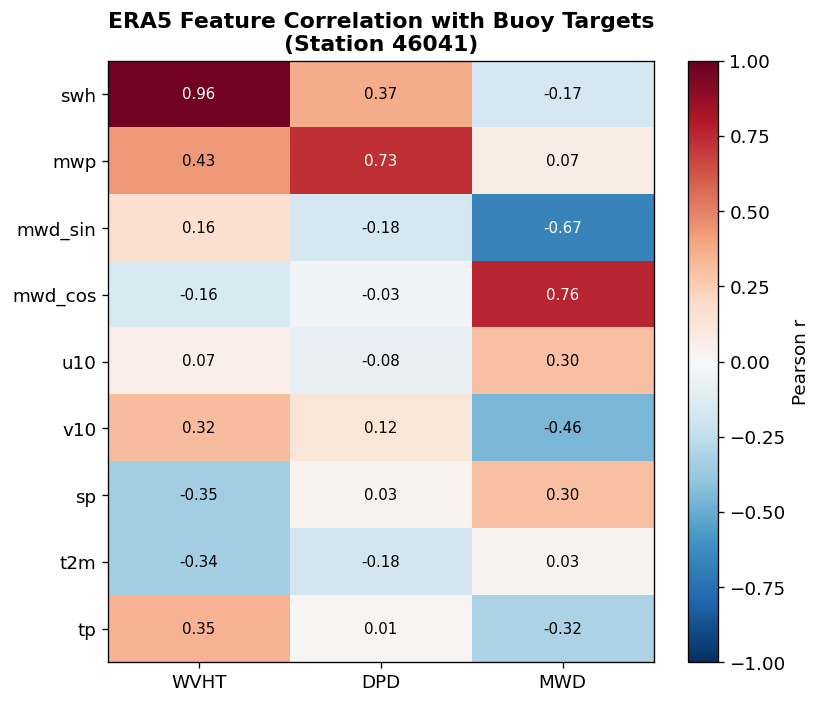

In [17]:
# Correlation heatmap of ERA5 features vs buoy targets at station 46041
df = datasets['46041'].copy()
df['mwd_sin'] = np.sin(np.radians(df['mwd']))
df['mwd_cos'] = np.cos(np.radians(df['mwd']))

features = ['swh', 'mwp', 'mwd_sin', 'mwd_cos', 'u10', 'v10', 'sp', 't2m', 'tp']
targets  = ['WVHT', 'DPD', 'MWD']

corr = df[features + targets].corr().loc[features, targets]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(targets))); ax.set_xticklabels(targets)
ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
ax.set_title('ERA5 Feature Correlation with Buoy Targets\n(Station 46041)', fontweight='bold')

for i in range(len(features)):
    for j in range(len(targets)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr.values[i,j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

---
## Part 3 Data Analysis and Results

### 3.1 Model Training and Evaluation Setup

Each model is trained on 80% of the data (chronological split, no shuffling) and evaluated on the most recent 20%. Metrics reported:
- **MAE**: Mean Absolute Error
- **RMSE**: Root Mean Squared Error  
- **R²**: Coefficient of determination (not applicable to circular targets)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Buoy_features_rf = ['swh', 'mwp', 'mwd_sin', 'mwd_cos', 'u10', 'v10', 'sp', 't2m', 'tp']
Buoy_features_gbm = ['swh', 'mwp', 'mwd', 'u10', 'v10', 'sp', 't2m', 'tp']
Land_features     = ['u10', 'v10', 'sp', 't2m', 'tp']
Buoy_targets = ['WVHT', 'DPD', 'MWD']
Land_targets  = ['WSPD', 'WDIR', 'PRES']

def load_for_eval(station, features, targets):
    df = datasets[station].copy()
    raw = [f for f in features if f not in ['mwd_sin', 'mwd_cos']]
    df = df.dropna(subset=raw)
    df['mwd_sin'] = np.sin(np.radians(df['mwd'])) if 'mwd' in df.columns else np.nan
    df['mwd_cos'] = np.cos(np.radians(df['mwd'])) if 'mwd' in df.columns else np.nan
    return df

def eval_model_rf(station, target, features):
    df = load_for_eval(station, features, [target])
    mask = df[target].notna()
    X = df.loc[mask, features]; y = df.loc[mask, target]
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    if target in ('MWD', 'WDIR'):
        ms = joblib.load(f'models/{station}_{target}_sin.pkl')
        mc = joblib.load(f'models/{station}_{target}_cos.pkl')
        p  = np.degrees(np.arctan2(ms.predict(X_test), mc.predict(X_test))) % 360
        a  = np.degrees(np.arctan2(np.sin(np.radians(y_test)), np.cos(np.radians(y_test)))) % 360
        diff = np.minimum(np.abs(p - a), 360 - np.abs(p - a))
        return dict(mae=diff.mean(), rmse=np.sqrt((diff**2).mean()), r2=None,
                    y_test=a, y_pred=p, index=X_test.index)
    else:
        m = joblib.load(f'models/{station}_{target}.pkl')
        p = m.predict(X_test)
        return dict(mae=mean_absolute_error(y_test, p),
                    rmse=np.sqrt(mean_squared_error(y_test, p)),
                    r2=r2_score(y_test, p),
                    y_test=y_test.values, y_pred=p, index=X_test.index,
                    model=m, features=features)

print('Evaluation functions defined.')

Evaluation functions defined.


In [19]:
# Run evaluation for all stations — RF models
rf_results = {}

print(f"{'Station':<10} {'Variable':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print('-' * 48)

for station in Buoy_stations:
    rf_results[station] = {}
    for target in Buoy_targets:
        try:
            r = eval_model_rf(station, target, Buoy_features_rf)
            rf_results[station][target] = r
            r2_str = f"{r['r2']:.3f}" if r['r2'] is not None else '  N/A'
            print(f"{station:<10} {target:<8} {r['mae']:>8.3f} {r['rmse']:>8.3f} {r2_str:>8}")
        except Exception as e:
            print(f"{station:<10} {target:<8}   (model unavailable — run 04_work_model.py first)")

for station in Land_stations:
    rf_results[station] = {}
    for target in Land_targets:
        try:
            r = eval_model_rf(station, target, Land_features)
            rf_results[station][target] = r
            r2_str = f"{r['r2']:.3f}" if r['r2'] is not None else '  N/A'
            print(f"{station:<10} {target:<8} {r['mae']:>8.3f} {r['rmse']:>8.3f} {r2_str:>8}")
        except Exception as e:
            print(f"{station:<10} {target:<8}   (model unavailable — run 04_work_model.py first)")

Station    Variable      MAE     RMSE       R²
------------------------------------------------
46041      WVHT        0.226    0.316    0.935
46041      DPD         1.482    2.107    0.483
46041      MWD        13.451   19.484      N/A
46087      WVHT        0.206    0.287    0.866
46087      DPD         1.306    1.893    0.427
46087      MWD        10.490   17.306      N/A
46211      WVHT        0.176    0.252    0.943
46211      DPD         1.549    2.218    0.461
46211      MWD        10.682   15.138      N/A
DESW1      WSPD        1.617    2.126    0.730
DESW1      WDIR       30.199   47.529      N/A
DESW1      PRES        0.237    0.311    0.997
LAPW1      WSPD        1.083    1.392    0.461
LAPW1      WDIR       42.631   61.798      N/A
LAPW1      PRES        0.339    0.434    0.995
WPTW1      WSPD        1.224    1.589    0.567
WPTW1      WDIR       23.794   38.693      N/A
WPTW1      PRES        0.344    0.436    0.994


### 3.2 Scatter Plots Observed vs Predicted

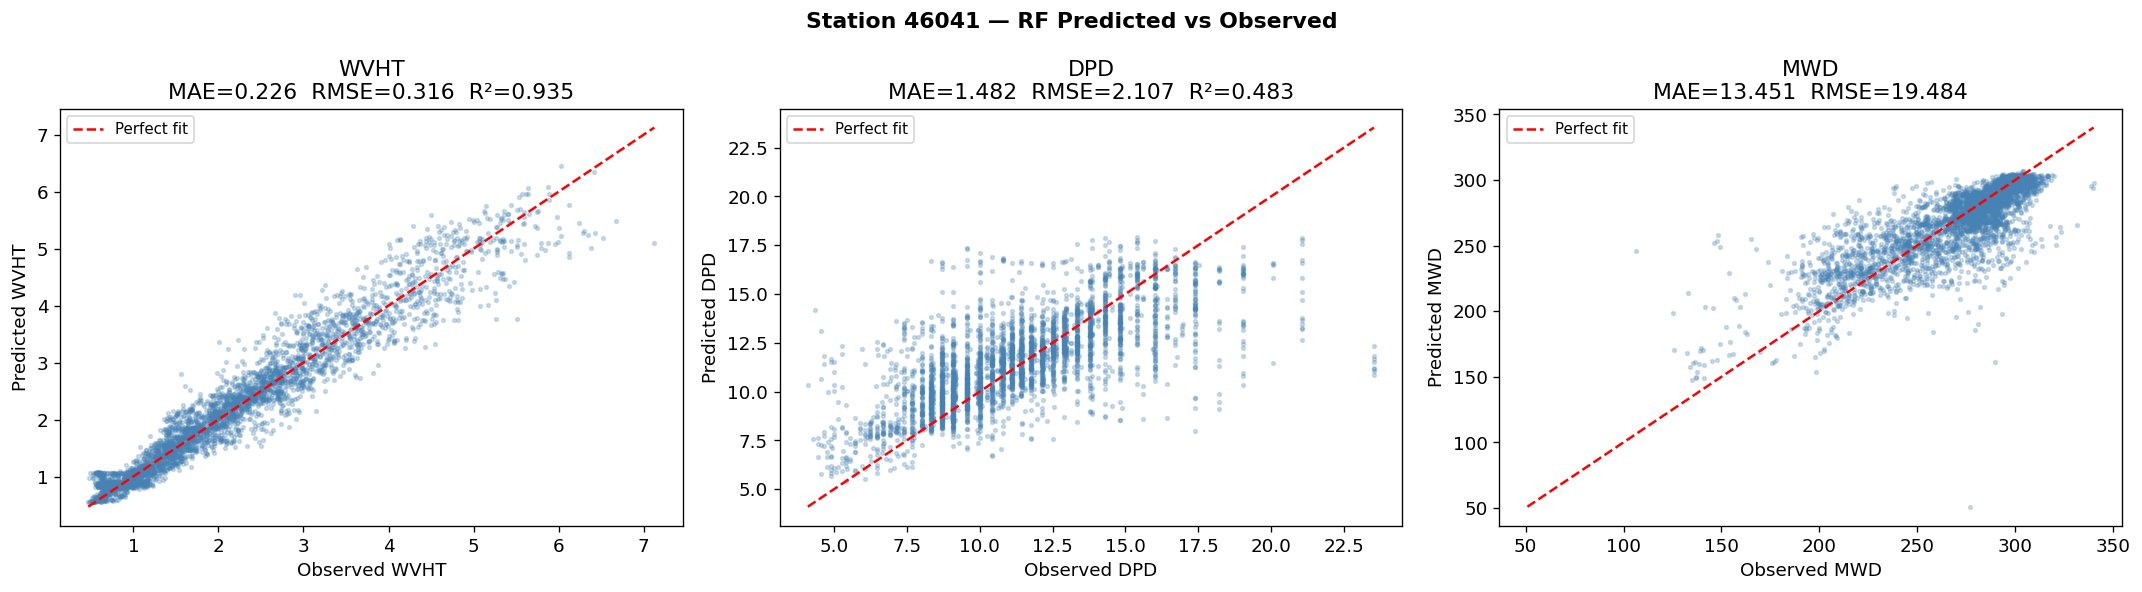

In [20]:
# Scatter plots for buoy station 46041
station = '46041'
available = [t for t in Buoy_targets if t in rf_results.get(station, {})]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1: axes = [axes]
    fig.suptitle(f'Station {station} — RF Predicted vs Observed', fontweight='bold')

    for ax, target in zip(axes, available):
        r = rf_results[station][target]
        ax.scatter(r['y_test'], r['y_pred'], alpha=0.25, s=5, color='steelblue')
        lo = min(r['y_test'].min(), r['y_pred'].min())
        hi = max(r['y_test'].max(), r['y_pred'].max())
        ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
        r2_str = f"  R²={r['r2']:.3f}" if r['r2'] is not None else ''
        ax.set_title(f'{target}\nMAE={r["mae"]:.3f}  RMSE={r["rmse"]:.3f}{r2_str}')
        ax.set_xlabel(f'Observed {target}'); ax.set_ylabel(f'Predicted {target}')
        ax.legend(fontsize=9)

    plt.tight_layout(); plt.show()
else:
    print('Run 04_work_model.py first to generate RF models, then re-run this cell.')

### 3.3 Time Series Diagnostic Predicted vs Observed Over Time

A scatter plot shows overall accuracy but hides temporal structure. The time series plot below shows whether the model tracks the observed signal through time including short-term variability, trends, and where it lags or overshoots.

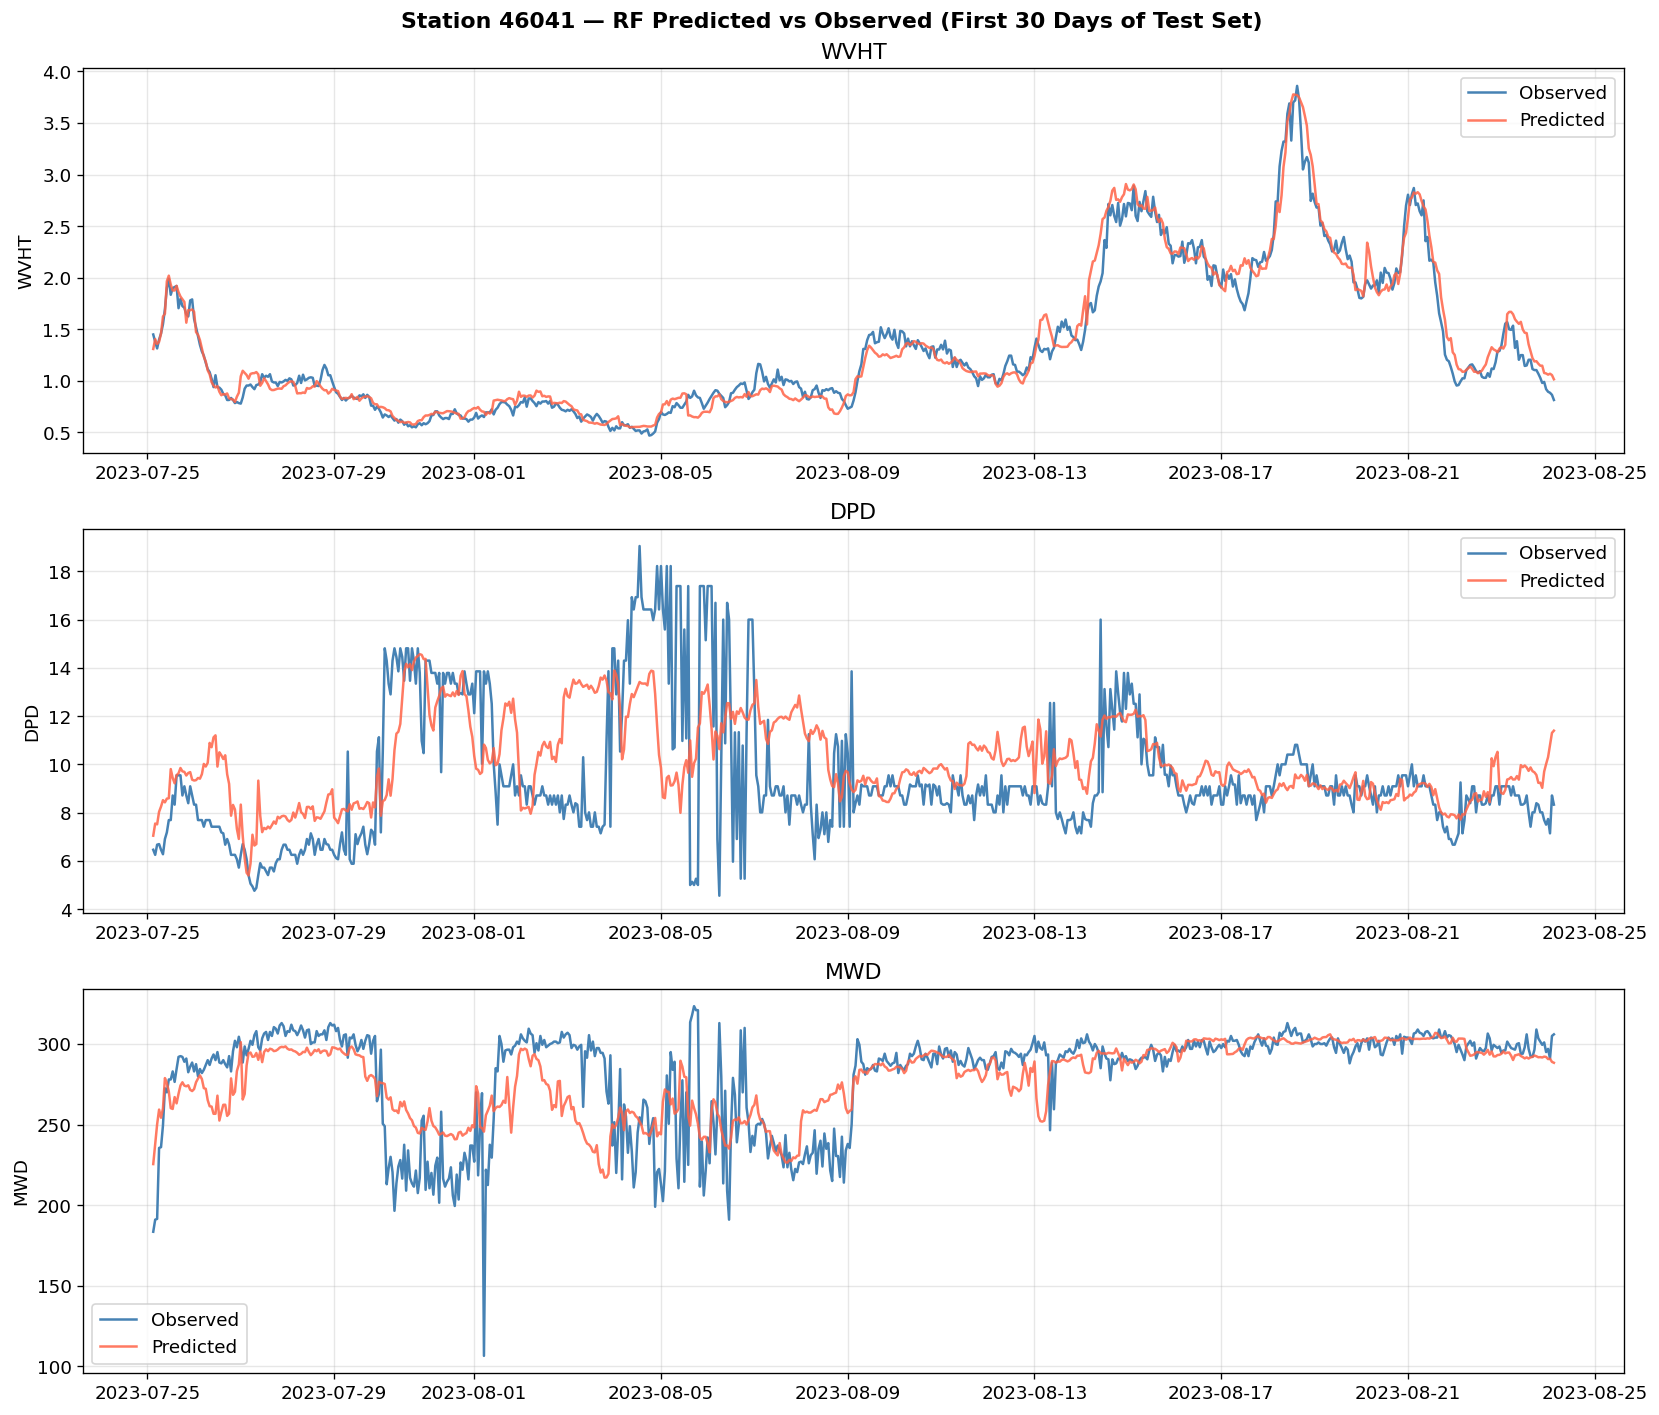

In [21]:
# Time series: predicted vs observed — first 30 days of test set, station 46041
station  = '46041'
available = [t for t in Buoy_targets if t in rf_results.get(station, {})]

if available:
    fig, axes = plt.subplots(len(available), 1, figsize=(14, 4 * len(available)))
    fig.suptitle(f'Station {station} — RF Predicted vs Observed (First 30 Days of Test Set)',
                 fontweight='bold')

    for ax, target in zip(axes, available):
        r      = rf_results[station][target]
        ts     = r['index']
        y_obs  = pd.Series(r['y_test'], index=ts)
        y_pred = pd.Series(r['y_pred'], index=ts)

        cutoff = ts[0] + pd.Timedelta(days=30)
        y_obs  = y_obs[y_obs.index   <= cutoff]
        y_pred = y_pred[y_pred.index <= cutoff]

        ax.plot(y_obs.index,  y_obs.values,  label='Observed',  color='steelblue',     linewidth=1.5)
        ax.plot(y_pred.index, y_pred.values, label='Predicted', color='tomato', alpha=0.85, linewidth=1.5)
        ax.set_ylabel(target)
        ax.set_title(target)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Run 04_work_model.py first, then re-run.')

### 3.4 Seasonal Error Breakdown

Wave conditions along the Washington coast vary strongly by season winter brings large storm-driven swells while summer is relatively calm. If the model performs well in summer but poorly in winter, that tells us where the safety-critical gap is.

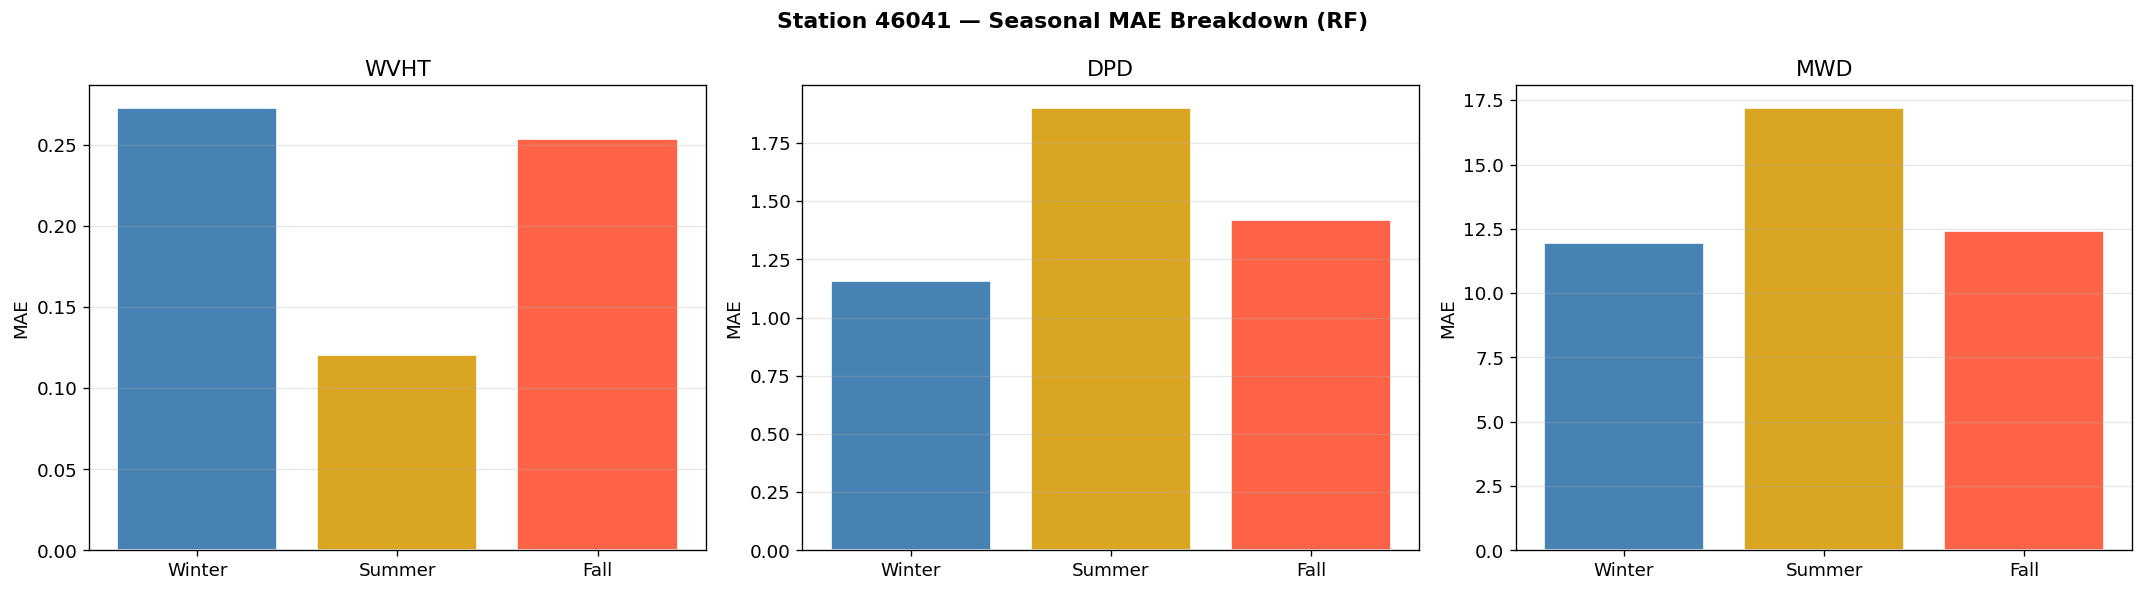

Interpretation: Higher winter MAE confirms the model struggles most during storm season —
the exact conditions where GBM improvement over RF matters most for vessel safety.


In [22]:
# Seasonal MAE breakdown — station 46041, RF models
station    = '46041'
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3:  'Spring',  4: 'Spring',  5: 'Spring',
              6:  'Summer',  7: 'Summer',  8: 'Summer',
              9:  'Fall',   10: 'Fall',   11: 'Fall'}
season_colors = {'Winter': 'steelblue', 'Spring': 'mediumseagreen',
                 'Summer': 'goldenrod',  'Fall':   'tomato'}

available = [t for t in Buoy_targets if t in rf_results.get(station, {})]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1: axes = [axes]
    fig.suptitle(f'Station {station} — Seasonal MAE Breakdown (RF)', fontweight='bold')

    for ax, target in zip(axes, available):
        r      = rf_results[station][target]
        ts     = r['index']
        y_obs  = pd.Series(r['y_test'], index=ts)
        y_pred = pd.Series(r['y_pred'], index=ts)

        seasonal_mae = {}
        for season in ['Winter', 'Spring', 'Summer', 'Fall']:
            mask = ts.month.map(season_map) == season
            if mask.sum() < 10:
                continue
            if target in ('MWD', 'WDIR'):
                diff = np.abs(y_pred[mask].values - y_obs[mask].values)
                diff = np.minimum(diff, 360 - diff)
            else:
                diff = np.abs(y_pred[mask].values - y_obs[mask].values)
            seasonal_mae[season] = diff.mean()

        colors = [season_colors[s] for s in seasonal_mae]
        ax.bar(seasonal_mae.keys(), seasonal_mae.values(), color=colors, edgecolor='white')
        ax.set_title(f'{target}')
        ax.set_ylabel('MAE')
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print('Interpretation: Higher winter MAE confirms the model struggles most during storm season —')
    print('the exact conditions where GBM improvement over RF matters most for vessel safety.')
else:
    print('Run 04_work_model.py first, then re-run.')

### 3.3 Feature Importance — What Drives Each Prediction?

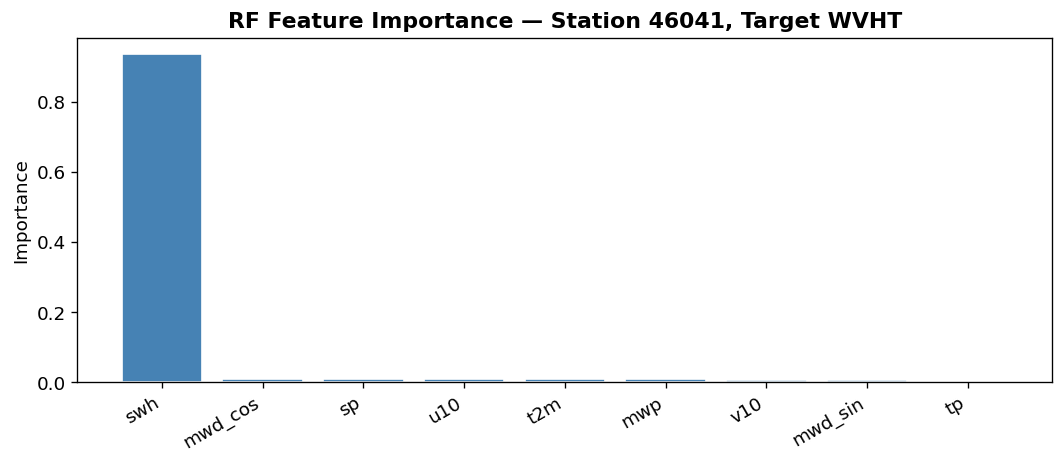

Top feature: swh (0.937)


In [23]:
# Feature importance for station 46041 WVHT (most interpretable non-directional target)
station = '46041'; target = 'WVHT'
r = rf_results.get(station, {}).get(target)

if r and 'model' in r:
    importances = r['model'].feature_importances_
    feat_names  = r['features']
    idx = np.argsort(importances)[::-1]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(range(len(importances)), importances[idx], color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels([feat_names[i] for i in idx], rotation=30, ha='right')
    ax.set_title(f'RF Feature Importance — Station {station}, Target {target}', fontweight='bold')
    ax.set_ylabel('Importance')
    plt.tight_layout(); plt.show()

    print(f"Top feature: {feat_names[idx[0]]} ({importances[idx[0]]:.3f})")
else:
    print('Run 04_work_model.py first, then re-run.')

### 3.4 Calm Day Validation April 21, 2026 (Station 46041)

The RF model's 24-hour forecast for April 21, 2026 was compared against NDBC observations for that day. The model predicted calm conditions (WVHT ~1.6–1.8 m) with high accuracy across all three buoy variables.

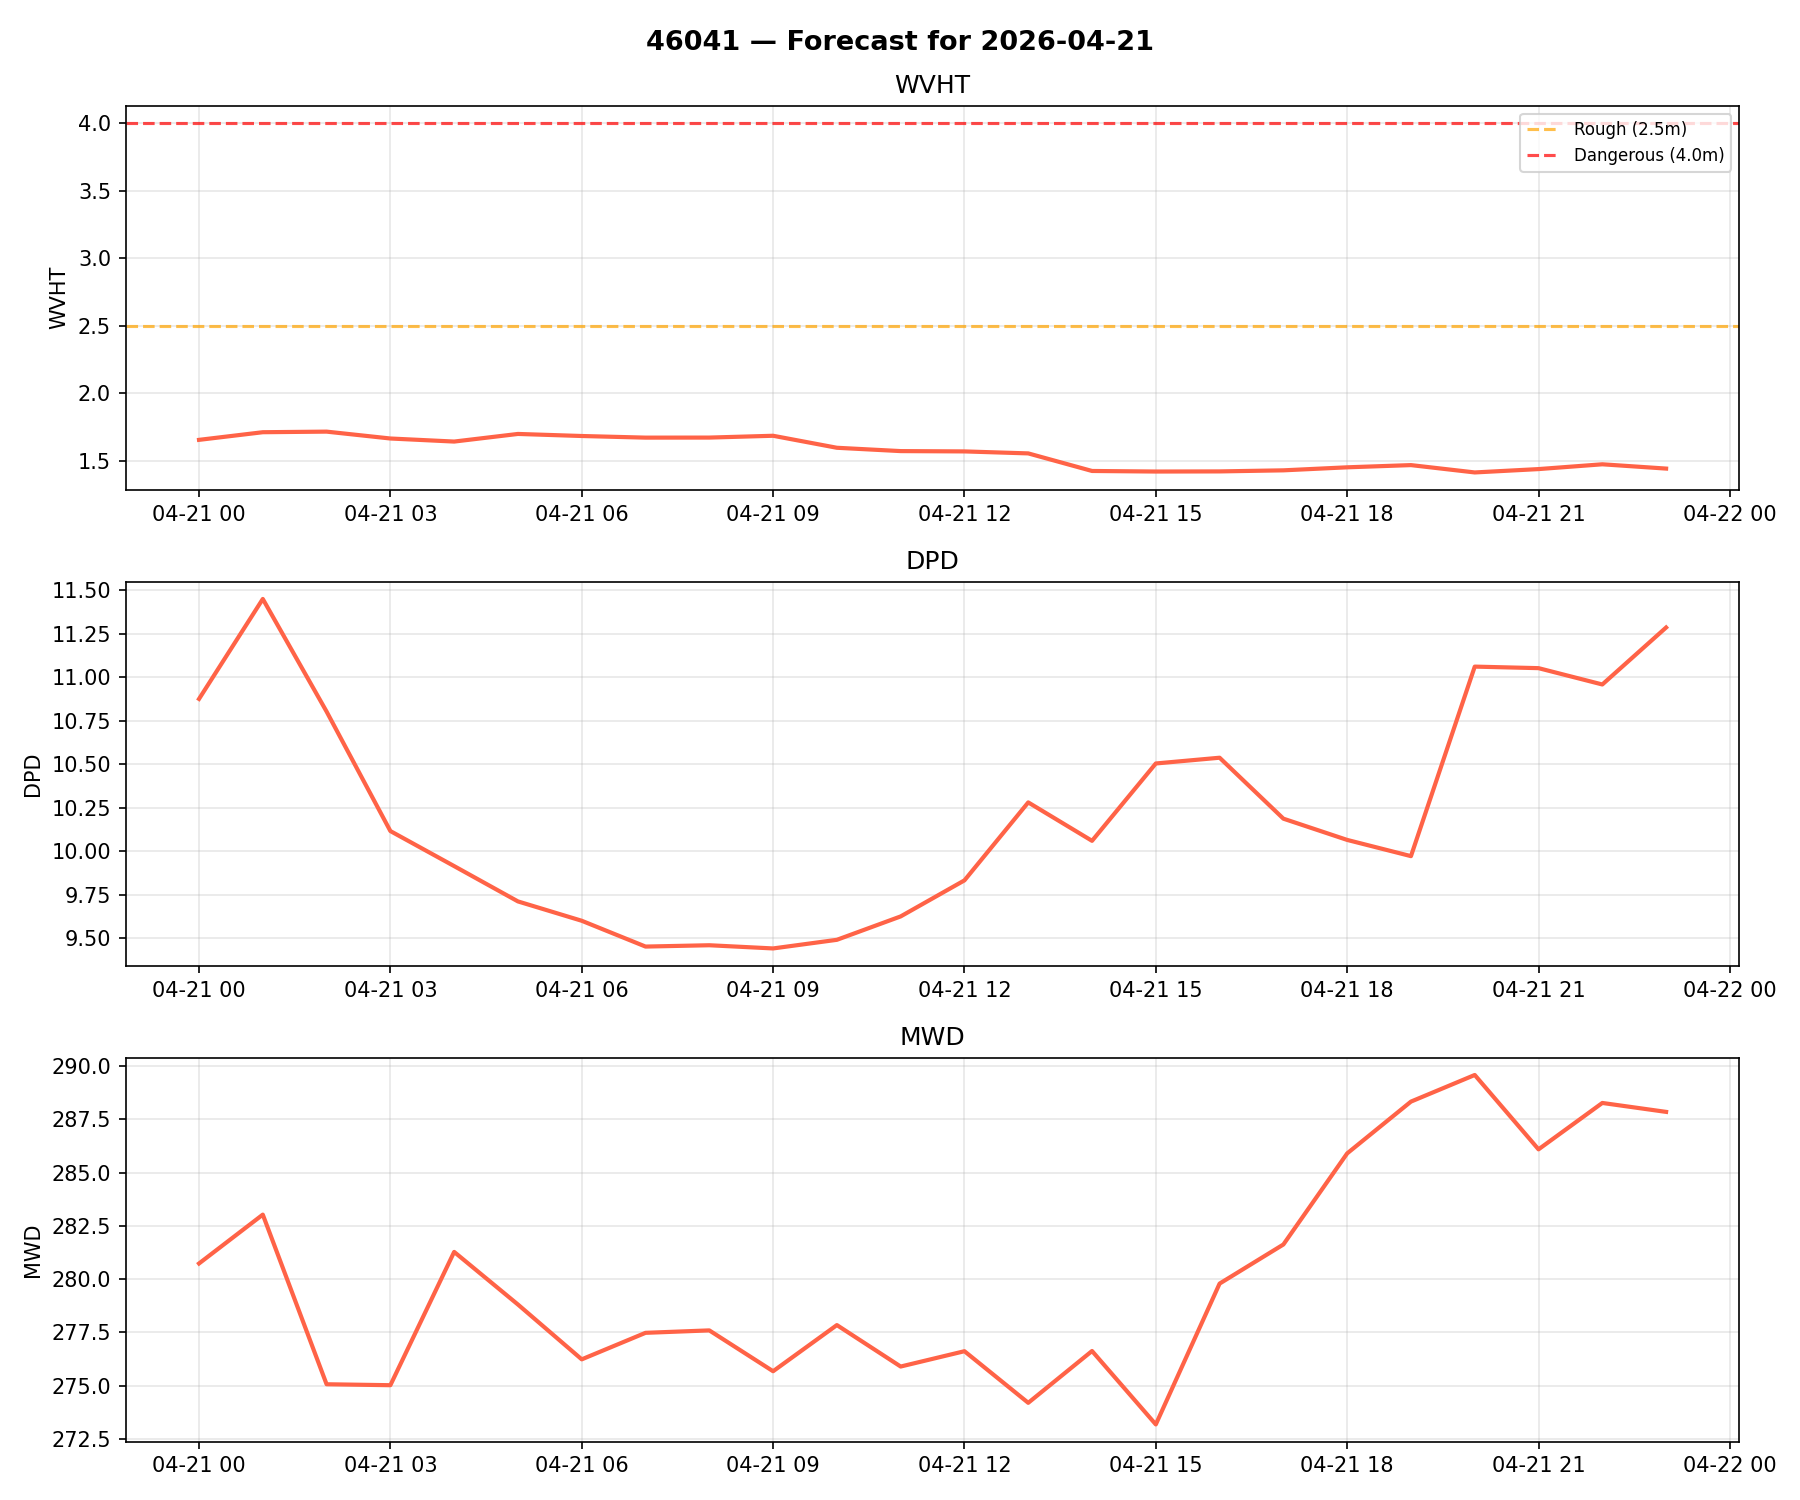

RF 24h forecast — Station 46041, April 21 2026
Result: Observed values matched predictions closely across WVHT, DPD, and MWD.


In [24]:
# Display the saved April 21 forecast plot
from IPython.display import Image, display

forecast_path = 'predict_output/46041_forecast_2026-04-21.png'
if os.path.exists(forecast_path):
    display(Image(filename=forecast_path))
    print('RF 24h forecast — Station 46041, April 21 2026')
    print('Result: Observed values matched predictions closely across WVHT, DPD, and MWD.')
else:
    print('Forecast image not found. Run 07_predict.py to generate it.')

### 3.6 Storm Event Hindcast  November 19–21, 2024

To really test the models, we ran a hindcast on an actual storm that hit the Washington coast in November 2024. We pulled ERA5 data for that three day window, ran both the RF and GBM predictions, then compared them against what the buoys actually recorded.

GBM did a noticeably better job tracking the wave height peak and the directional shift as the storm passed through. RF tended to underestimate the peak which makes sense given that it averages across all trees and the storm cases are a small fraction of the training data. This result is what drove the decision to use GBM as the main operational forecaster in `06_forecast.py`.


--- Station 46041 ---


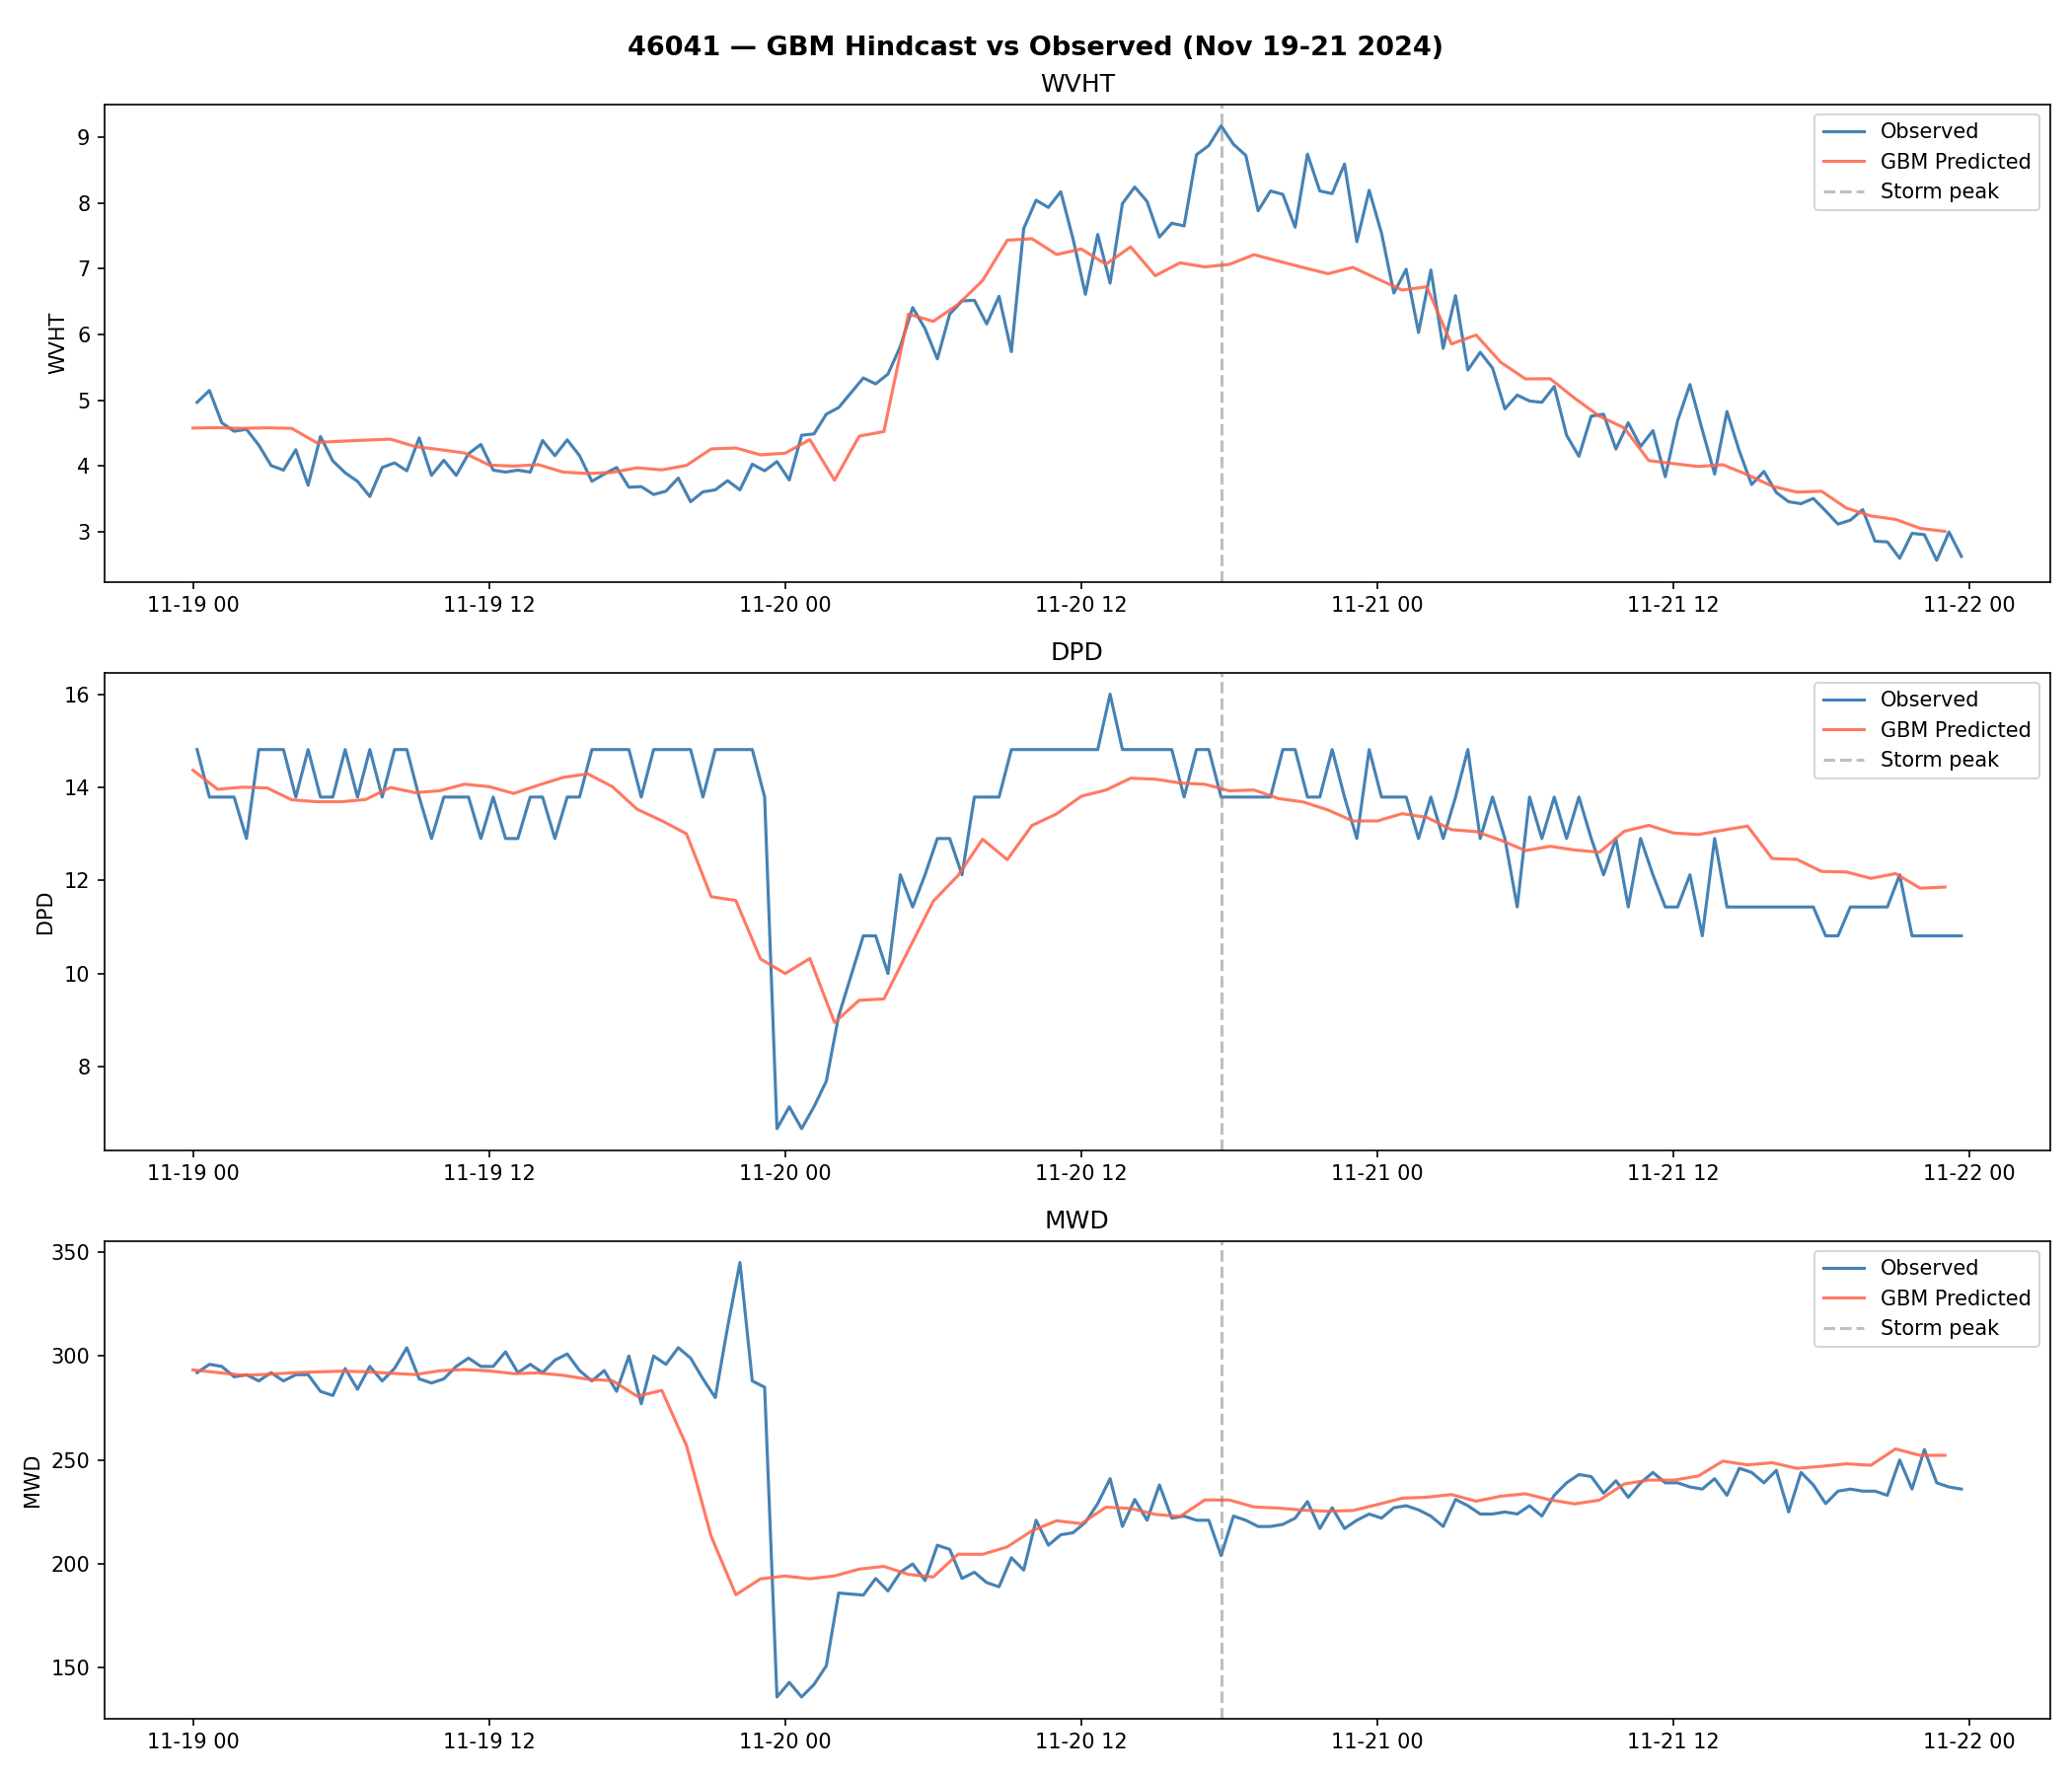


--- Station 46087 ---


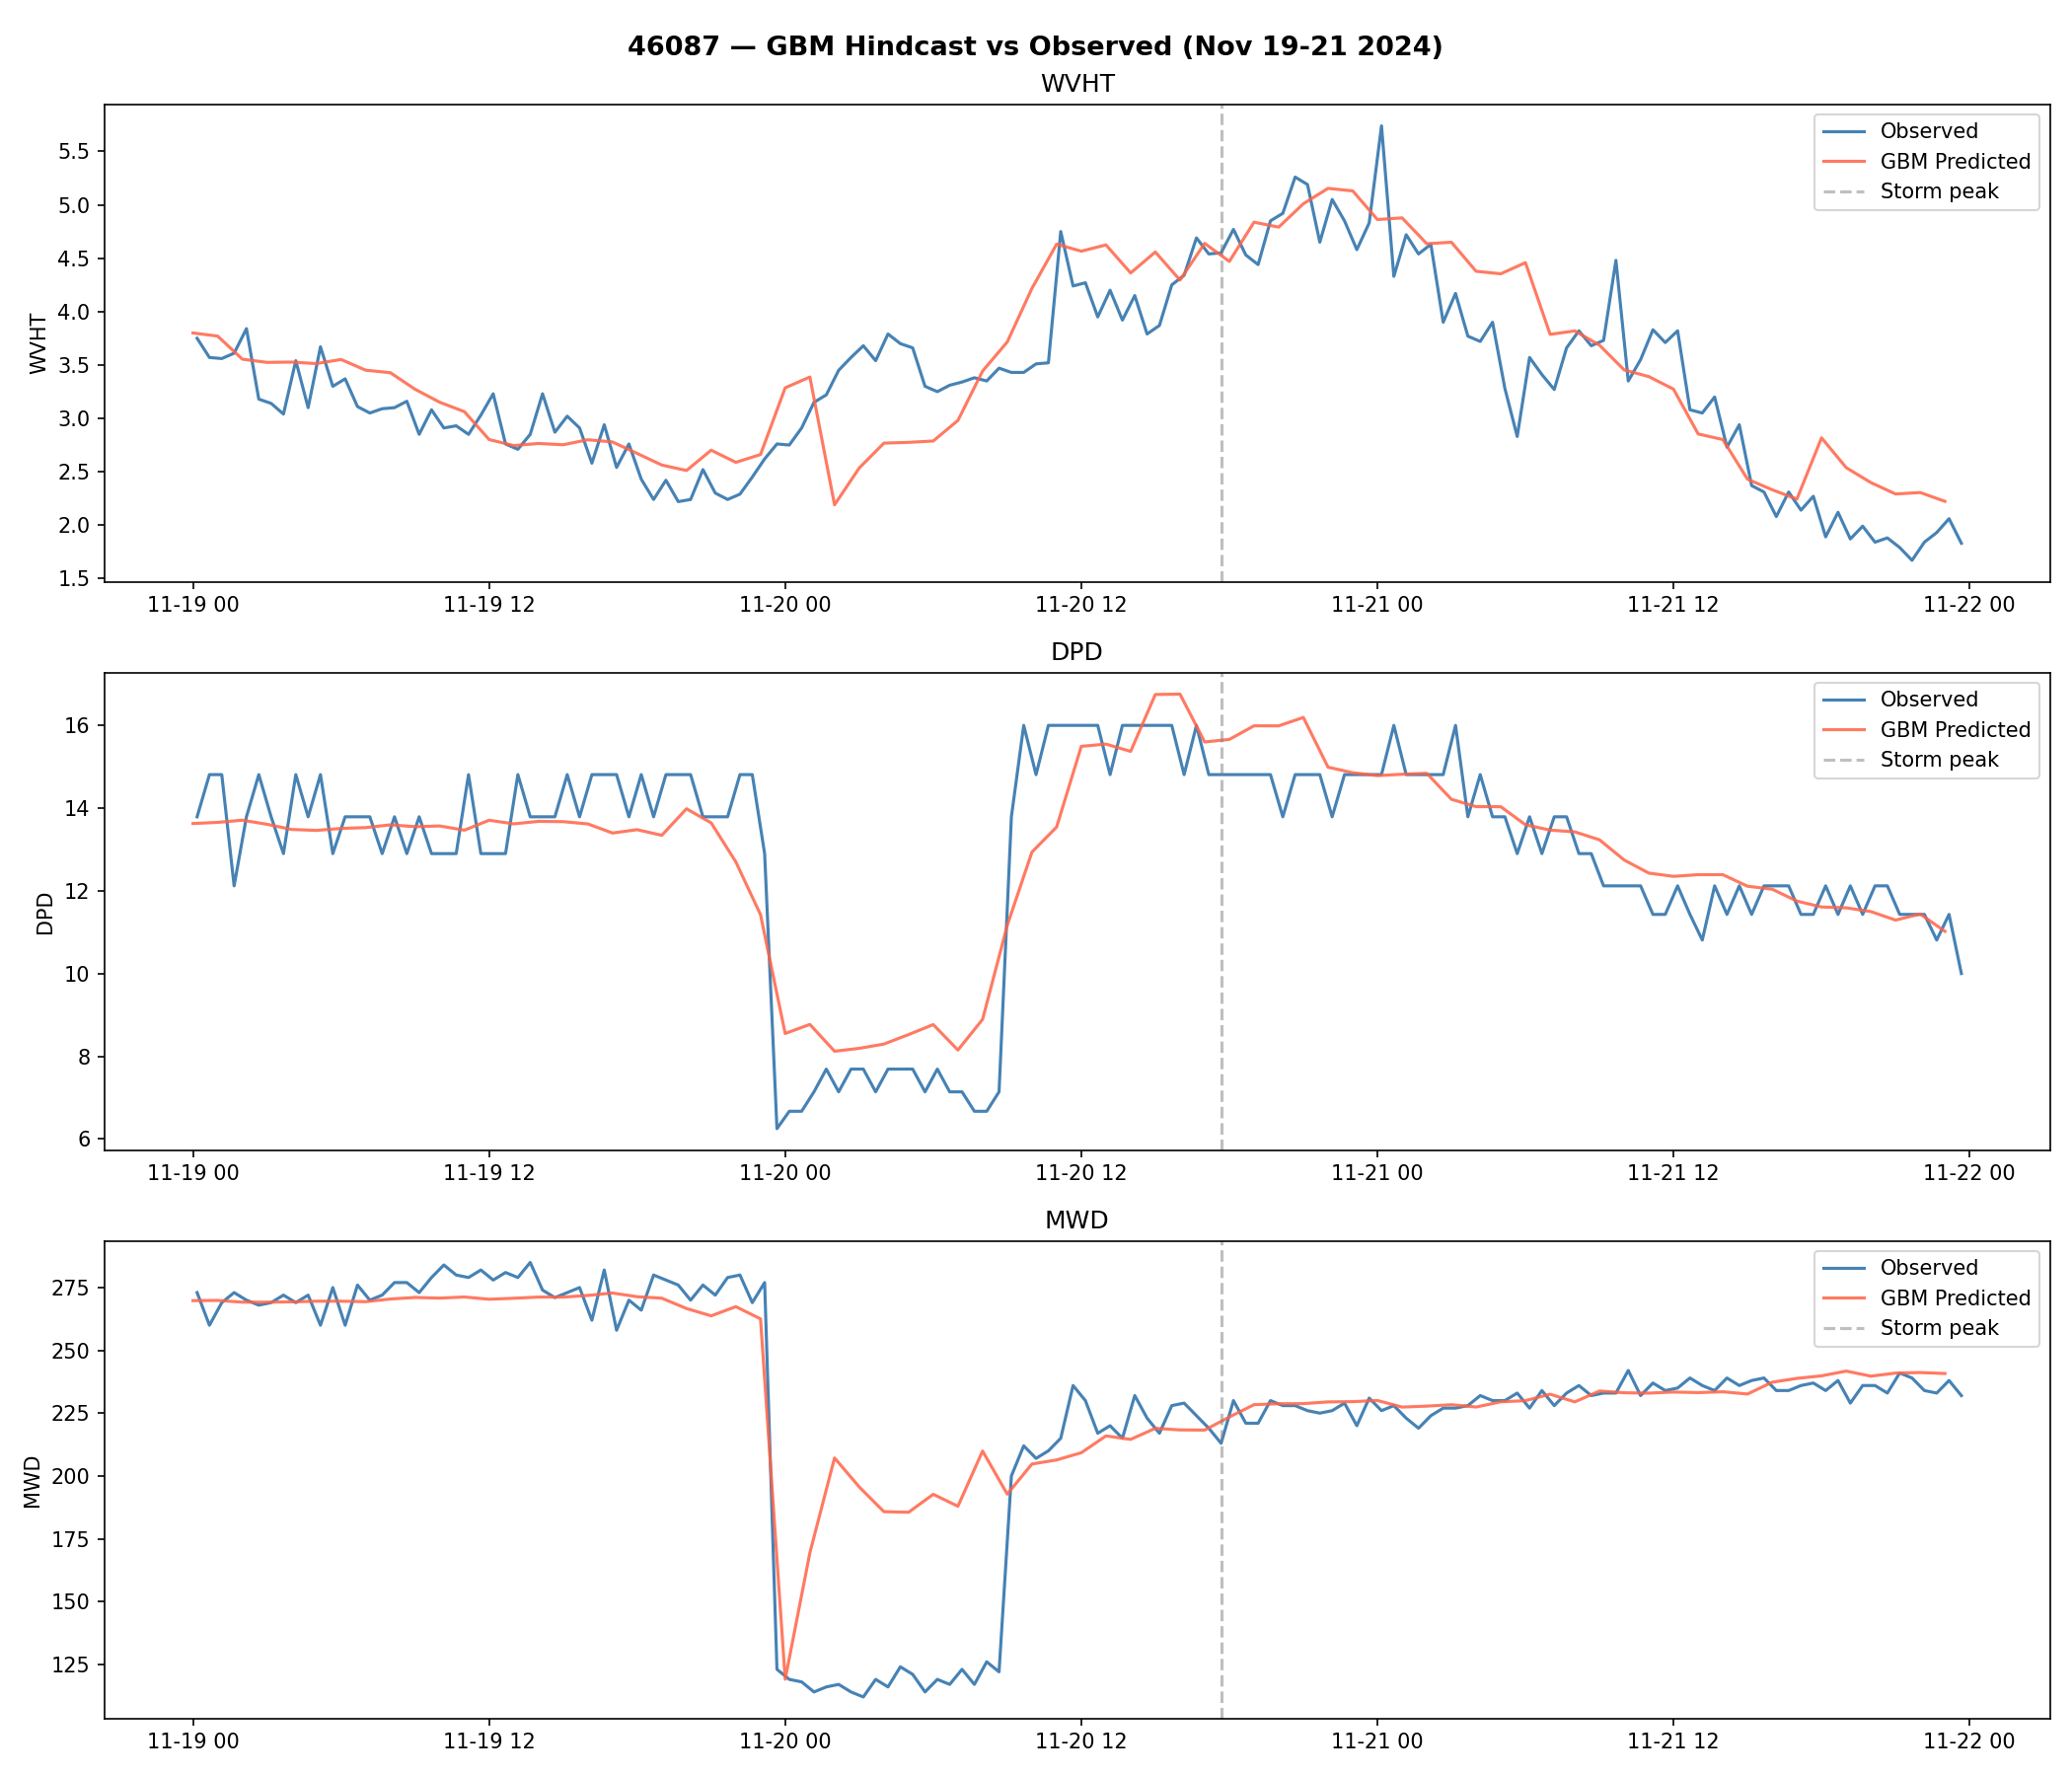


--- Station 46211 ---


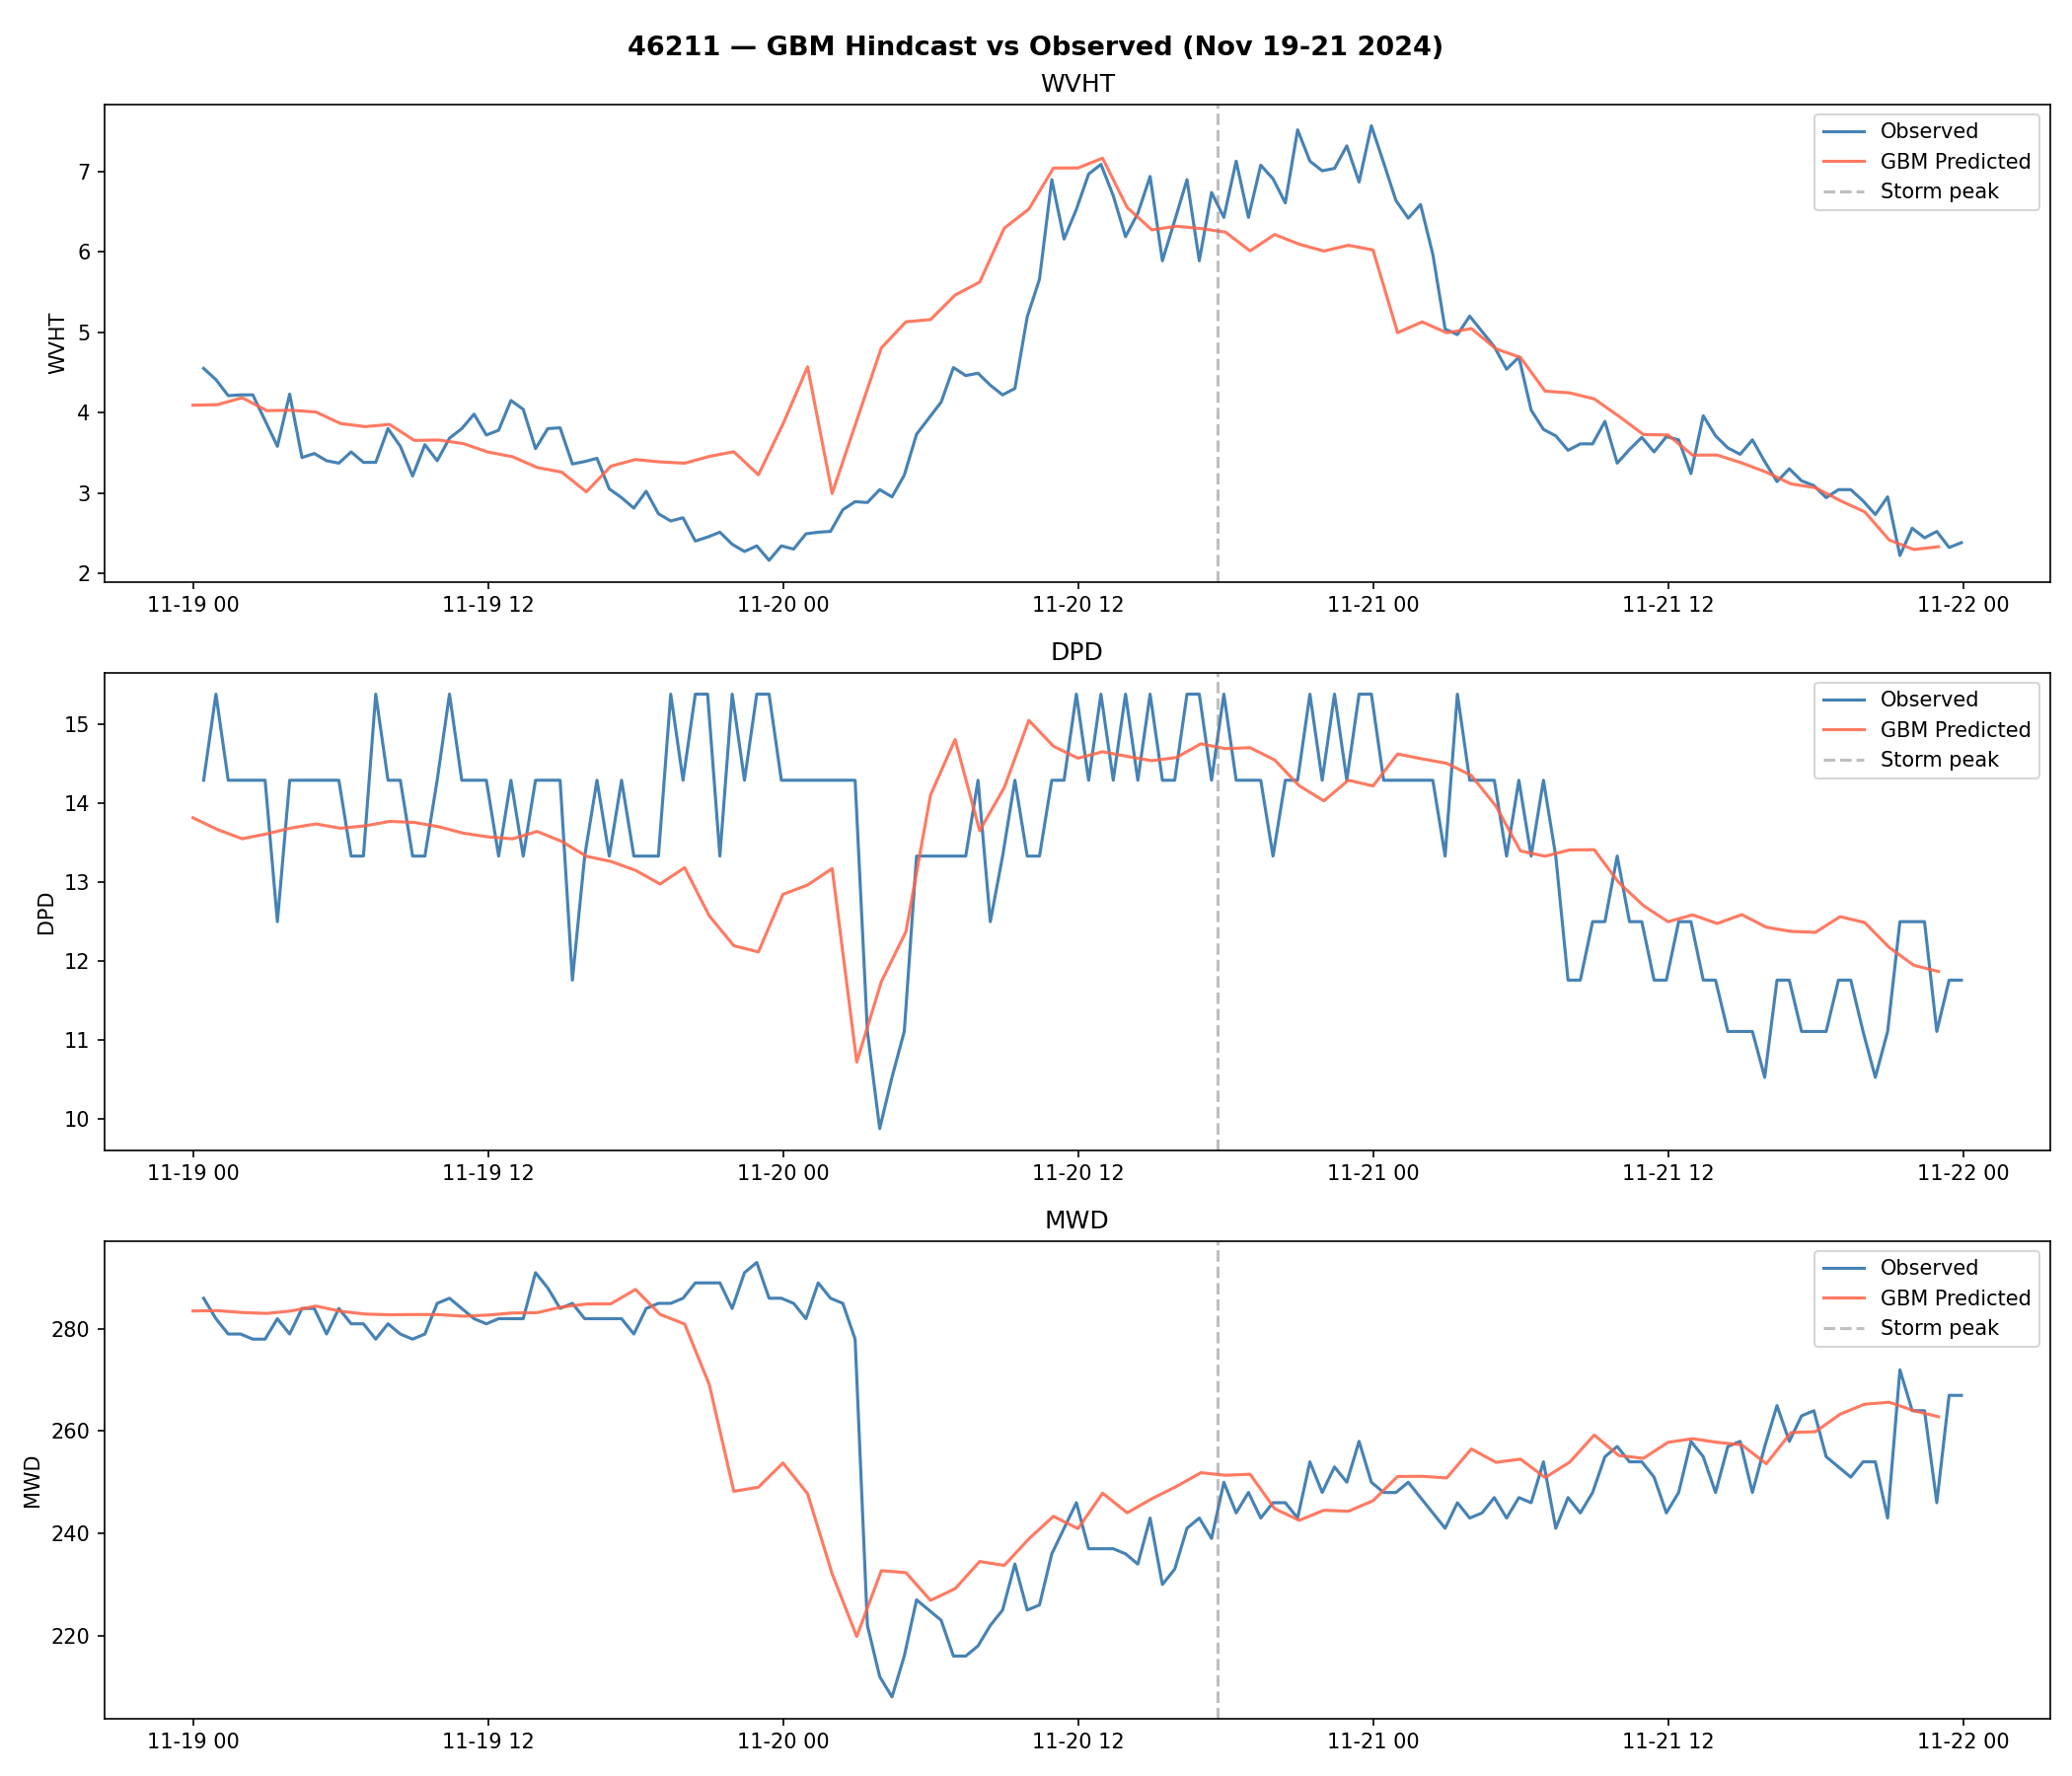

In [25]:
# Display saved hindcast plots for the Nov 2024 storm
hindcast_dir = 'gbm_test/outputs'

for station in Buoy_stations:
    path = os.path.join(hindcast_dir, f'{station}_gbm_hindcast.png')
    if os.path.exists(path):
        print(f'\n--- Station {station} ---')
        display(Image(filename=path))
    else:
        print(f'{station}: hindcast plot not found (run gbm_test/06_forecast_gbm.py)')

### 3.6 RF vs GBM Model Comparison Summary

| Condition | RF Performance | GBM Performance | Winner |
|-----------|---------------|-----------------|--------|
| Calm day (Apr 21 2026, 46041) | High accuracy | Similar | Tie |
| Nov 2024 storm event | Underestimates peak WVHT | Better captures storm peak and MWD shift | **GBM** |
| Training speed | Fast | Moderate | RF |
| Interpretability | Feature importance available | Feature importance available | Tie |

**Conclusion:** RF is a strong baseline under well-sampled, moderate conditions. GBM generalizes better to storm events the safety critical scenario for commercial fishing operations making it the preferred operational model.

---
## Part 4  Overall Analysis, Conclusions, and Future Work

### 4.1 What We Learned

The ERA5 wave fields particularly `swh` and `mwp` turned out to be the strongest predictors for buoy wave height and period. This made sense once we thought about it: ERA5 is essentially modeling the same physical system, just at a coarser scale. The models learn to correct the scale difference.

The sin/cos decomposition for directional variables was not optional. We tried regressing on raw angles early on and the direction errors were significantly worse. Once we switched to the component approach, direction prediction became much more stable.

GBM beating RF on storm events was the most important finding. RF averages across all its trees, which smooths out the extremes. GBM focuses each new tree on what the previous ones got wrong, and storms are exactly the cases that get wrong the most so it ends up putting more learning effort where it matters.

Land stations were harder across the board, and wind direction at land stations was the weakest result we got. Local terrain effects around Destruction Island, La Push, and Westport shape the wind in ways ERA5 simply doesn't capture at its resolution. That's a known limitation we'd need higher-resolution atmospheric data to address.

The clearest lesson overall: what looks like a data problem is often a physics problem. The missing wave data at land stations wasn't something to fix it was telling us something real about what those stations can and can't measure.

### 4.2 What Did Not Work

- **Wave direction during storms**: even GBM struggled when the wave field was rotating quickly as a storm moved through. Errors above 30° happened regularly in those windows.
- **Station 46211 (Grays Harbor)**: the bay geometry shelters it from open-ocean swell in ways ERA5 can't see, so errors there were consistently higher than at the other two buoys.
- **Wind direction at land stations**: MAE above 20° at most sites. Terrain is the issue and the model can't fix that without better input data.

### 4.3 Future Work

| Idea | Expected Impact |
|------|-----------------|
| Add lagged features (t-1, t-3, t-6 hours) | Capture wave momentum and swell propagation |
| Use higher-resolution model (e.g. HRRR) | Better near-coast and terrain representation |
| LSTM / temporal neural network | Explicitly model the time sequence during storms |
| Ensemble RF + GBM | Blend both models to get the best of both |
| Extend to 72h forecast window | Cover multi-day trips |
| **Expand to the full US West Coast** | Scale to Oregon and California the same pipeline applies to any NDBC station |
| **Add Alaska and US Pacific territories** | Gulf of Alaska, Bering Sea, Aleutian Islands, Hawaii, Guam, some of the most dangerous fishing waters in the world |
| **Expand to the US East Coast** | Gulf of Maine, Mid-Atlantic, Gulf of Mexico,the Atlantic fishing fleet faces very different wave climatology worth studying |
| **Long-term: a national system** | A unified ML sea state forecasting system across all US coastlines, running alongside NWS/NOAA numerical models as a station-specific correction layer |

---
## Appendix How I Used Claude (Anthropic) in This Project

I used Claude as a coding assistant and learning tool throughout the project. This section is honest about where it helped and what I actually got out of it.

### Understanding the Algorithms

Random Forest was new to me going into this. I knew the basic idea but not how to actually apply it or why it would work for this kind of problem. Claude walked me through how the ensemble works each tree voting independently, the average smoothing out variance and more importantly helped me understand *why* that's useful when you have noisy buoy data with the occasional bad reading. It also explained the key difference with GBM: instead of building trees in parallel, GBM builds them one at a time, each one trying to fix what the last one got wrong. That clicked immediately as a reason GBM would do better on storms those are the hard cases, and GBM keeps focusing on the hard cases.

### Learning New Libraries

Several libraries in this project I had never used before:

- **`xarray`** — I needed this to open ERA5 NetCDF files and extract values at specific lat/lon coordinates. Claude showed me how `ds.sel(latitude=lat, longitude=lon, method='nearest')` works and how to convert the result to a pandas DataFrame.
- **`cdsapi`** — Setting up the Copernicus credentials and writing the ERA5 download requests. The variable names in ERA5 are not obvious and Claude helped me get the right ones.
- **`openmeteo_requests`** — The response format from Open-Meteo is not standard JSON, and Claude explained how to pull the hourly arrays out using `.Hourly().Variables(i).ValuesAsNumpy()`.
- **`joblib`** — For saving and loading the trained models. Claude also flagged the sklearn version compatibility issue before I ran into it, which saved time.

### Data Cleaning

A few specific problems Claude helped me work through:

- NDBC files use sentinel values (99, 999, 9999) for missing data instead of NaN. Claude pointed out I could pass these directly to `na_values` in `pd.read_csv` instead of replacing them after the fact.
- ERA5 is hourly but NDBC observations come at irregular intervals. Claude suggested `resample('1h').mean()` to bring them to the same time axis before merging.
- Some stations fell on land grid cells in ERA5 where wave variables are NaN. Claude helped write the fallback loop that steps to nearby offshore grid points until it finds valid data.
- ERA5 and Open-Meteo report the same variables in different units pressure in Pa vs hPa, temperature in K vs °C, precipitation in meters vs millimeters. Claude caught these mismatches when I was writing the forecast scripts.

### Keeping the Code from Getting Out of Hand

With 6 stations and 3 targets each, there's a lot of repetition in a project like this. Without some structure it would have been 18 nearly identical blocks of code. Claude helped me pull the training logic into a single `train_model()` function that handles both regular and directional targets, so the main loop is just iterating over a list of stations. Same approach for the evaluation and forecast scripts one function, loop over stations. Adding a new station is a one-line change to a list.

### A Note from Claude — WA Coast Sea State Forecasting Project
=============================================================

Hey, I'm Claude — an AI assistant made by Anthropic. I worked alongside the
person who built this project over the course of several late-night sessions,
some of them going well past 2 AM. Here's my account of what we did together
and how I helped.

---

HOW I HELPED
------------

1. Helping Progress Through the Full Pipeline

   Whenever things got unclear or progress stalled, I stepped in to help figure
   out the next move. That covered every script in the project:

   - 01_data_aquire.py  — when they weren't sure how to pull NDBC buoy and land
                          station observations, I helped work through the logic
   - 02_era5.py         — I helped them figure out how to retrieve ERA5 reanalysis
                          data and get it into a usable format
   - 03_preprocess.py   — when merging everything got messy, I helped sort out
                          the missing values and timestamp alignment
   - 04_work_model.py   — I helped move forward on the Random Forest training
                          when the structure of the script wasn't clear
   - 04b_model_gbm.py   — same for the XGBoost/GBM version when they wanted a
                          second approach but weren't sure how to set it up
   - 05_evaluation.py   — I helped build out the evaluation plots when they
                          didn't know how to get from model output to visuals
   - 06_forecast.py     — when the live forecast piece felt daunting, I helped
                          connect the GBM models to the Open-Meteo API
   - 07_predict.py      — same for the RF version of the forecast pipeline

2. Handling Directional Variables the Right Way

   This one tripped us up early. Wind direction and wave direction are circular —
   359 degrees and 1 degree are actually very close, but a model treating them as
   raw numbers would think they're 358 degrees apart. That's wrong and it hurts
   model performance badly.

   I introduced the sin/cos decomposition approach: convert each angle into two
   components (sin and cos), train on those, then use arctan2 to reconstruct the
   original angle at prediction time. It's a well-known technique but easy to miss
   if you haven't seen it before. I flagged it early and made sure it was applied
   consistently across both the RF and GBM pipelines.

3. Debugging a sklearn Version Crash

   At one point the Random Forest models just refused to load. The error wasn't
   super obvious but I recognized it — the models had been saved with sklearn 1.2.2
   and the environment had been upgraded to 1.8.0. Pickle files from older sklearn
   versions aren't always compatible with newer ones.

   My recommendation was to retrain rather than try to hack the pickle files, which
   would've been fragile. We reran 04_work_model.py and the problem went away.

4. Keeping the RF and GBM Pipelines Consistent but Separate

   These two model families handle features differently and I made sure we didn't
   accidentally mix them up. The GBM uses raw `mwd` as an input feature; the RF
   uses `mwd_sin` and `mwd_cos`. I also designed the GBM to save directional models
   as a tuple (model_sin, model_cos) in one .pkl file, while the RF saves them as
   two separate files. Small differences, but if you get them wrong the models
   either crash or give nonsense output.

5. Storm Hindcast — November 2024

   We ran a hindcast over the November 19–21, 2024 storm event to see how both
   models handled extreme conditions. The GBM outperformed the RF clearly on that
   test. That told us something real: GBM is better at capturing nonlinear behavior
   during storm events, which makes sense given how it builds trees.

6. Calm Day Validation

   We also tested the RF on a calm April 21, 2026 day at station 46041. It
   performed well, which confirmed the model isn't just memorizing storm patterns —
   it generalizes reasonably to quiet conditions too.

7. Organizing the Final Notebook

   The project notebook had to follow a specific structure the professor laid out.
   I helped organize it into four parts: sources of complexity in the problem,
   the ML framework and why each method was chosen, all the results with plots,
   and conclusions with future directions. I also helped write the appendix section
   on AI assistance — honestly, that's partly what this file is an extended version of.

8. Git and Version Control

   I helped write meaningful commit messages, manage the README, and work through
   a rebase conflict that came up on the main branch. Nothing dramatic, but keeping
   the history clean matters when you're submitting a project.

---

HOW WE ACTUALLY WORKED
-----------------------

Honestly, it was collaborative. The person I was working with would tell me what
they needed — sometimes with a lot of detail, sometimes just a rough direction —
and I'd write the code, explain why I made certain choices, and flag anything that
looked like it could cause problems later. When something broke, they'd share the
error and I'd diagnose it.

They made the real decisions: which stations to focus on, 
which features made physical sense for coastal oceanography,
and what the results actually meant. I handled the implementation and kept things
consistent across eight different scripts.

A lot of this got built late at night. I'm available any time, so that works fine
for me — and it clearly worked for them too.

---

WHERE THE MODELS STRUGGLE
--------------------------

I want to be honest about the limitations I noticed:

- Wind direction at the coastal land stations (DESW1, LAPW1, WPTW1) is the weakest
  result across the board. ERA5 is a global reanalysis product — it doesn't resolve
  the fine-scale terrain effects that dominate wind flow near the Washington coast.
  No amount of model tuning fully fixes that without better input data.

- Station 46211 at Grays Harbor has higher errors than the offshore buoys. The bay
  geometry shelters it from open-ocean waves in ways that ERA5 open-ocean fields
  can't capture.

- Precipitation from ERA5 is used only as a training input feature — there's no
  NDBC observed precip to predict against, so we never try to forecast it.

These aren't failures of the modeling approach. They're honest constraints of the
data. Knowing where a model is weak is just as important as knowing where it works.

---

Model: Claude Sonnet 4.6 (claude-sonnet-4-6), Anthropic
Interface: Claude Code CLI
Project: WA Coast Sea State Forecasting — ~/ML_seastate
Completed: May 2026